In [1]:
import cv2 as cv
import numpy as np
import supervision as sv
import os
import matplotlib.pyplot as plt

In [2]:
# Función de preprocesamiento general
def preprocess(img):
    gray = cv.imread(img, cv.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f'No se pudo cargar la imagen: {img}')
    image = cv.GaussianBlur(gray, (3, 3), 0)
    return image

In [3]:
# Función de ajuste del pattern (crop + negativo)
def process_pattern(patt_orig,
                    crop_left = 60,
                    crop_right = 100,
                    crop_up = 50,
                    crop_down = 30):

    h, w = patt_orig.shape

    patt_crop = patt_orig[crop_up: h - crop_down, crop_left:w - crop_right]
    pattern = cv.bitwise_not(patt_crop)

    sv.plot_image(pattern)
    print('El tamaño del pattern es', pattern.shape)
    return pattern

In [4]:
# Función de armado de pirámide del pattern
def scale_img(img1, img2, min, levels):
    w_img1 = img1.shape[1]
    w_img2 = img2.shape[1]
    max_scale = w_img2 / w_img1
    scales = np.linspace(min, max_scale, levels)
    processed_imgs = []

    for scale in scales:
        resized_img = cv.resize(img1, None, fx=scale, fy=scale)
        processed_img = cv.GaussianBlur(resized_img, (3, 3), 0)
        processed_imgs.append(processed_img)
    return processed_imgs

In [5]:
# Cargamos las imágenes. Paso a negativo coca_retro_1.png
image_list = [
    'images/COCA-COLA-LOGO.jpg',
    'images/coca_logo_1.png',
    'images/coca_logo_2.png',
    'images/coca_multi.png',
    'images/coca_retro_1.png',
    'images/coca_retro_2.png',
    'images/logo_1.png'
]

prep_images = {}

print('El tamaño de las imágenes es:') 
for file in image_list:
    img_name = os.path.basename(file)
    prep_images[img_name] = preprocess(file)   
    print(f'-{img_name}: {prep_images[img_name].shape}')

prep_images['coca_retro_1.png'] = cv.bitwise_not(prep_images['coca_retro_1.png'])

El tamaño de las imágenes es:
-COCA-COLA-LOGO.jpg: (1389, 1389)
-coca_logo_1.png: (500, 207)
-coca_logo_2.png: (363, 233)
-coca_multi.png: (598, 799)
-coca_retro_1.png: (493, 715)
-coca_retro_2.png: (429, 715)
-logo_1.png: (450, 687)


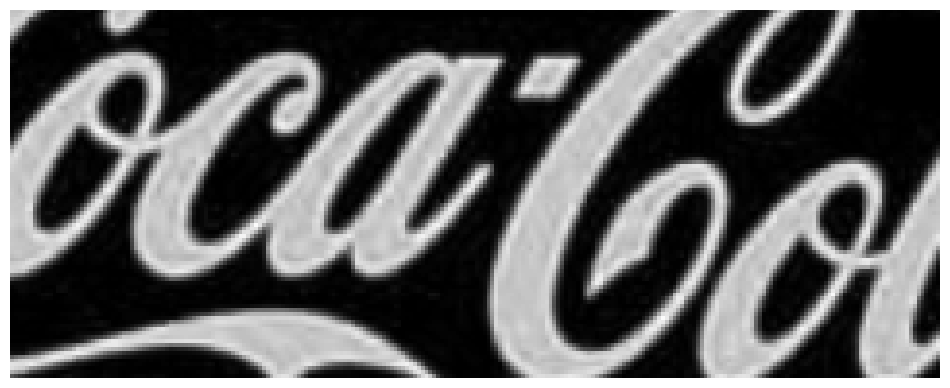

El tamaño del pattern es (95, 240)


In [6]:
# Ajustamos el pattern
patt_orig = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
pattern = process_pattern(patt_orig)


Resultado del procesamiento de COCA-COLA-LOGO.jpg
- Piramide Ok
- Mejor score = 0.75 en el template 54


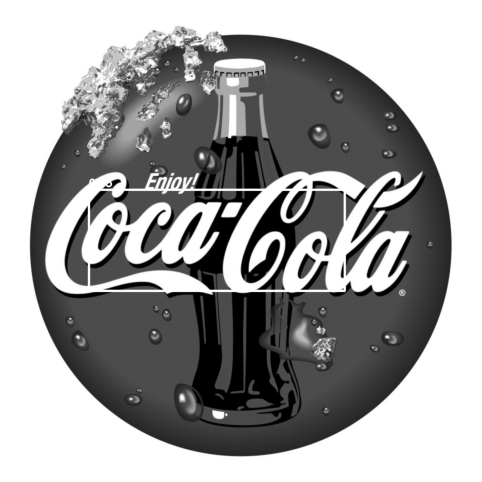

Resultado del procesamiento de coca_logo_1.png
- Piramide Ok
- Mejor score = 0.86 en el template 42


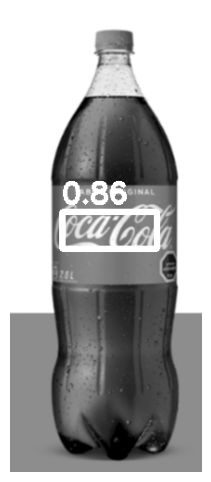

Resultado del procesamiento de coca_logo_2.png
- Piramide Ok
- Mejor score = 0.67 en el template 63


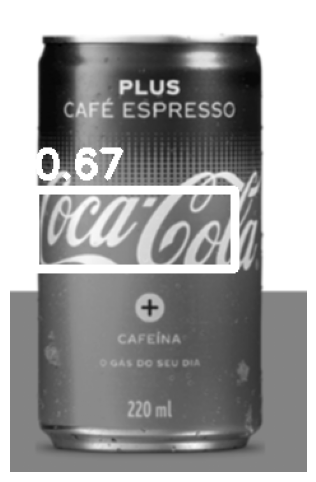

Resultado del procesamiento de coca_multi.png
- Piramide Ok
- Mejor score = 0.83 en el template 4


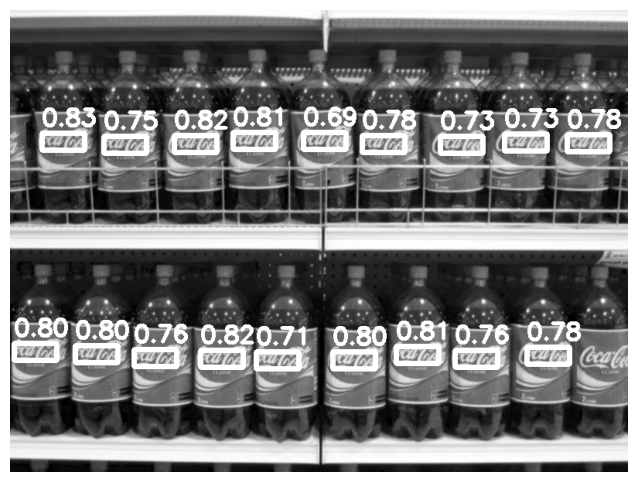

Resultado del procesamiento de coca_retro_1.png
- Piramide Ok
- Mejor score = 0.65 en el template 42


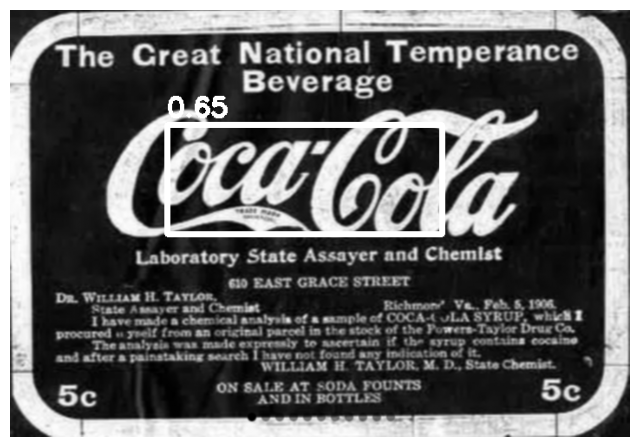

Resultado del procesamiento de coca_retro_2.png
- Piramide Ok
- Mejor score = 0.67 en el template 10


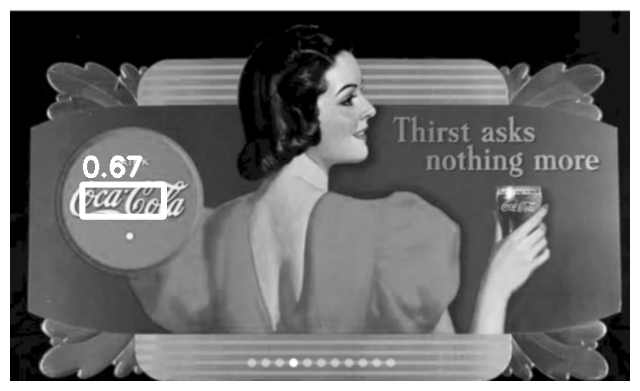

Resultado del procesamiento de logo_1.png
- Piramide Ok
- Mejor score = 0.63 en el template 23


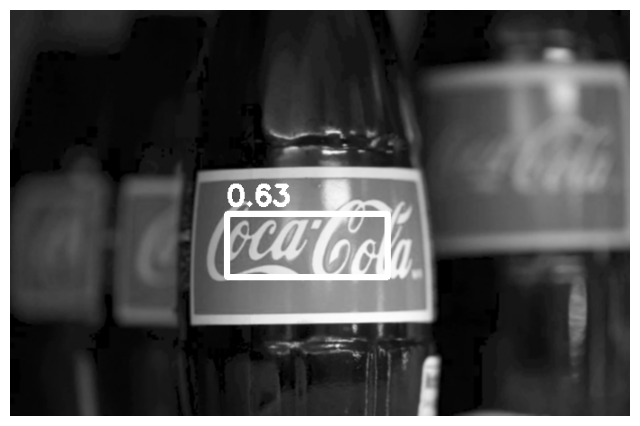

In [7]:
# Corremos la función de procesamiento para todas las imágenes preprocesadas
processed_patterns_by_image = {}

for image_name, image in prep_images.items():
    print(f'Resultado del procesamiento de {image_name}')

    # Armamos la pirámide y guardamos también las escalas
    w_img1 = pattern.shape[1]
    w_img2 = image.shape[1]
    max_scale = w_img2 / w_img1
    scales = np.linspace(0.1, max_scale, 100)

    processed_patterns = []
    for scale in scales:
        resized_img = cv.resize(pattern, None, fx=scale, fy=scale)
        processed_img = cv.GaussianBlur(resized_img, (3, 3), 0)
        processed_patterns.append(processed_img)

    processed_patterns_by_image[image_name] = {
        "patterns": processed_patterns,
        "scales": scales
    }

    print('- Piramide Ok')

    # Determinamos qué nivel de la pirámide tiene el mejor match
    img_gray = prep_images[image_name]
    processed_patterns = processed_patterns_by_image[image_name]["patterns"]
    scales = processed_patterns_by_image[image_name]["scales"]

    best_score = -1
    best_template_idx = None

    for i, template in enumerate(processed_patterns):
        res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)
        _, max_val, _, _ = cv.minMaxLoc(res)

        if max_val > best_score:
            best_score = max_val
            best_template_idx = i

    print(f'- Mejor score = {best_score:.2f} en el template {best_template_idx}')

    # Tomamos el mejor template y su escala
    template = processed_patterns[best_template_idx]
    best_scale = scales[best_template_idx]

    # Match con el template ganador
    w, h = template.shape[::-1]
    res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)

    threshold = 0.6
    loc = np.where(res >= threshold)

    boxes = []
    conf_scores = []

    for pt in zip(*loc[::-1]):

        # Tomo el nivel de confiaza de cada punto
        conf_score = float(res[pt[1], pt[0]])
        boxes.append([pt[0], pt[1], w, h])
        conf_scores.append(conf_score)

    # Non-Maximum Suppression
    indices = cv.dnn.NMSBoxes(boxes, conf_scores, score_threshold=threshold, nms_threshold=0.3)

    for i in indices:
        i = int(i)
        x, y, bw, bh = boxes[i]
        conf_score = conf_scores[i]

        cv.rectangle(img_gray, (x, y), (x + bw, y + bh), 255, 6)
        cv.putText(img_gray, f"{conf_score:.2f}", (x, y - 10),
                   cv.FONT_HERSHEY_SIMPLEX, 1, 255, 3)

    plt.figure(figsize=(8,6))
    plt.imshow(img_gray, cmap='gray')
    plt.axis("off")
    plt.show()

    